In [1]:
!pip install nltk wordcloud

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import nltk

from collections import Counter
from wordcloud import WordCloud

In [3]:
url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/sms.tsv"

df = pd.read_csv(url, sep="\t", header=None, names=["label", "text"])

df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
print("Dataset size:", df.shape)

Dataset size: (5572, 2)


In [5]:
print("\nColumn names:")
print(df.columns.tolist())


Column names:
['label', 'text']


In [6]:
print("\nDataset information:")
df.info()


Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [7]:
print(df.isnull().sum())

label    0
text     0
dtype: int64


In [8]:
print("Duplicate records:", df.duplicated().sum())

df = df.drop_duplicates()

print("Records after removing duplicates:", df.shape)

Duplicate records: 403
Records after removing duplicates: (5169, 2)


In [9]:
def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    text = re.sub(r"#", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text"]].head()

,text,clean_text
0,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in a wkly comp to win fa cup final ...
3,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,"Nah I don't think he goes to usf, he lives aro...",nah i dont think he goes to usf he lives aroun...


In [10]:
all_words = " ".join(df["clean_text"])

words = all_words.split()

word_count = Counter(words)

top_words = word_count.most_common(15)

print(top_words)

[('i', 2132), ('to', 2078), ('you', 2036), ('a', 1308), ('the', 1240), ('u', 1033), ('and', 923), ('in', 820), ('is', 796), ('me', 743), ('my', 684), ('for', 666), ('your', 619), ('it', 574), ('of', 560)]


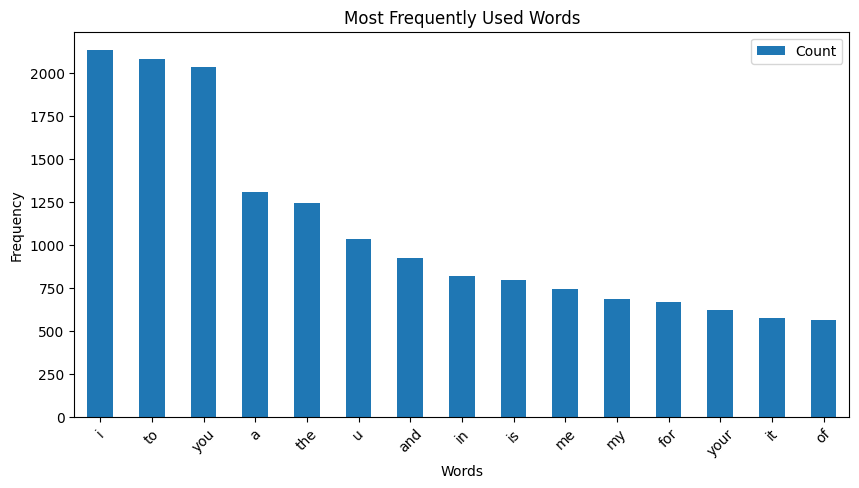

In [11]:
words_df = pd.DataFrame(top_words, columns=["Word", "Count"])

words_df.plot(
    x="Word",
    y="Count",
    kind="bar",
    figsize=(10, 5)
)

plt.title("Most Frequently Used Words")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

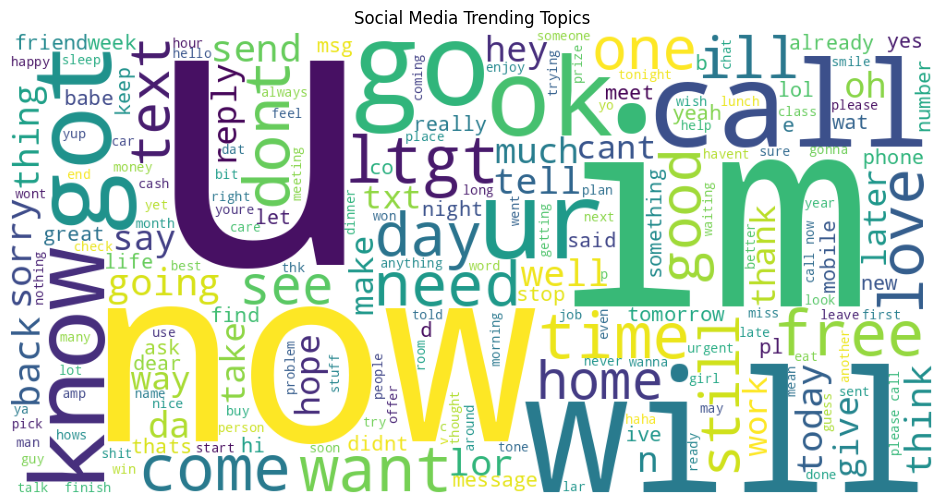

In [12]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Social Media Trending Topics")
plt.show()

In [13]:
interest_words = [
    "love",
    "work",
    "food",
    "music",
    "movie",
    "school",
    "family",
    "friend",
    "travel",
    "happy"
]

interest_count = {}

for word in interest_words:
    interest_count[word] = word_count[word]

print(interest_count)

{'love': 183, 'work': 87, 'food': 22, 'music': 16, 'movie': 20, 'school': 25, 'family': 19, 'friend': 45, 'travel': 4, 'happy': 96}


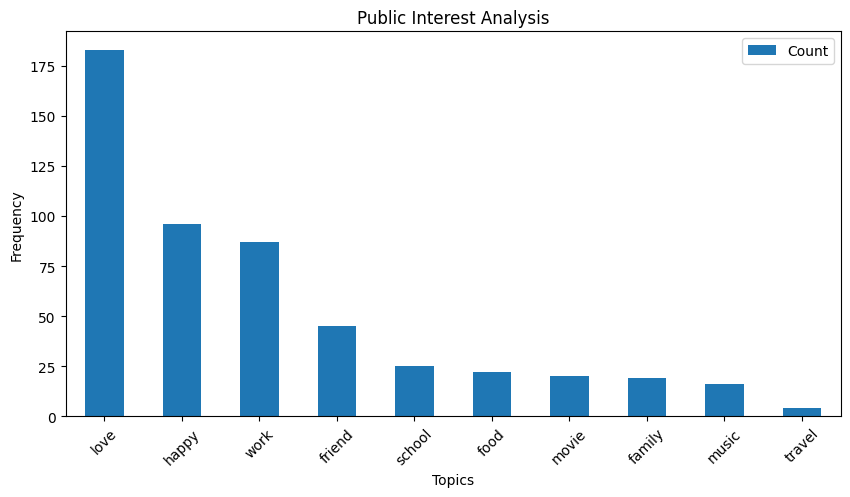

In [14]:
interest_df = pd.DataFrame(
    list(interest_count.items()),
    columns=["Topic", "Count"]
)

interest_df = interest_df.sort_values(
    by="Count",
    ascending=False
)

interest_df.plot(
    x="Topic",
    y="Count",
    kind="bar",
    figsize=(10, 5)
)

plt.title("Public Interest Analysis")
plt.xlabel("Topics")
plt.ylabel("Frequency")
plt.xticks(rotation=45)

plt.show()

In [15]:
print("Social Media Trend Analysis Completed Successfully.")
print("The text data was cleaned and preprocessed.")
print("Frequently used words were identified.")
print("Trending topics were analyzed.")
print("Public interests were studied.")
print("Visualizations were created to present the findings.")

Social Media Trend Analysis Completed Successfully.
The text data was cleaned and preprocessed.
Frequently used words were identified.
Trending topics were analyzed.
Public interests were studied.
Visualizations were created to present the findings.
